# Лабораторная работа №3

In [7]:
import os
import subprocess
import numpy as np
import time
import matplotlib.pyplot as plt

def load_matrix(filename, size):
    if not os.path.isfile(filename):
        raise FileNotFoundError(f"Матрица не найдена: {filename}")
    return np.loadtxt(filename, dtype=int).reshape((size, size))

def verify_multiplication(A_file, B_file, C_file, size):
    A = load_matrix(A_file, size)
    B = load_matrix(B_file, size)
    C_computed = load_matrix(C_file, size)
    C_expected = np.dot(A, B)
    
    if np.array_equal(C_computed, C_expected):
        print(f"✅ Верификация успешна для {size}x{size}")
    else:
        print(f"❌ Ошибка верификации для {size}x{size}")

def run_mpi_test(size, num_procs, exe_path="matrix_mult_mpi.exe"):
    A_file = f"data/{size}/matrix_A.txt"
    B_file = f"data/{size}/matrix_B.txt"
    C_file = f"data/{size}/matrix_C.txt"
    
    if not os.path.isfile(exe_path):
        raise FileNotFoundError(f"Не найден MPI-исполняемый файл: {exe_path}")
    
    cmd = [
        "mpiexec", "-n", str(num_procs),
        exe_path, str(size), A_file, B_file, C_file
    ]
    print(f"\nЗапуск MPI: size={size}, procs={num_procs}")
    t0 = time.time()
    subprocess.run(cmd, check=True)
    elapsed = time.time() - t0
    print(f"Время: {elapsed:.4f} сек")
    
    verify_multiplication(A_file, B_file, C_file, size)
    return (size, elapsed)

def plot_results(results):
    plt.figure(figsize=(8, 6))
    for procs, data in results.items():
        sizes, times = zip(*data)
        plt.plot(sizes, times, marker='o', label=f"{procs} proc")
    plt.xlabel("Размер матрицы N")
    plt.ylabel("Время, сек")
    plt.title("MPI: время умножения матриц")
    plt.grid(True)
    plt.legend(title="Процессов")
    plt.tight_layout()
    plt.show()


In [15]:
sizes = [10, 100, 200, 300, 400, 500, 600, 700, 800, 900, 1000]
exe_path = "matrix_mult/matrix_mult/x64/Debug/matrix_mult.exe"
results  = {}

# === Тестирование с 1 процессом ===
procs = 1
res   = []
for size in sizes:
    res.append(run_mpi_test(size, procs, exe_path=exe_path))
results[procs] = res


Запуск MPI: size=10, procs=1
Время: 0.1964 сек
✅ Верификация успешна для 10x10

Запуск MPI: size=100, procs=1
Время: 0.2449 сек
✅ Верификация успешна для 100x100

Запуск MPI: size=200, procs=1
Время: 0.6492 сек
✅ Верификация успешна для 200x200

Запуск MPI: size=300, procs=1
Время: 1.5662 сек
✅ Верификация успешна для 300x300

Запуск MPI: size=400, procs=1
Время: 2.9800 сек
✅ Верификация успешна для 400x400

Запуск MPI: size=500, procs=1
Время: 5.4281 сек
✅ Верификация успешна для 500x500

Запуск MPI: size=600, procs=1
Время: 8.4532 сек
✅ Верификация успешна для 600x600

Запуск MPI: size=700, procs=1
Время: 12.9220 сек
✅ Верификация успешна для 700x700

Запуск MPI: size=800, procs=1
Время: 18.7080 сек
✅ Верификация успешна для 800x800

Запуск MPI: size=900, procs=1
Время: 26.0516 сек
✅ Верификация успешна для 900x900

Запуск MPI: size=1000, procs=1
Время: 38.8147 сек
✅ Верификация успешна для 1000x1000


In [16]:
procs = 2
res   = []
for size in sizes:
    res.append(run_mpi_test(size, procs, exe_path=exe_path))
results[procs] = res


Запуск MPI: size=10, procs=2
Время: 0.1715 сек
✅ Верификация успешна для 10x10

Запуск MPI: size=100, procs=2
Время: 0.2491 сек
✅ Верификация успешна для 100x100

Запуск MPI: size=200, procs=2
Время: 0.5376 сек
✅ Верификация успешна для 200x200

Запуск MPI: size=300, procs=2
Время: 1.1335 сек
✅ Верификация успешна для 300x300

Запуск MPI: size=400, procs=2
Время: 2.0668 сек
✅ Верификация успешна для 400x400

Запуск MPI: size=500, procs=2
Время: 3.5600 сек
✅ Верификация успешна для 500x500

Запуск MPI: size=600, procs=2
Время: 5.5520 сек
✅ Верификация успешна для 600x600

Запуск MPI: size=700, procs=2
Время: 8.2230 сек
✅ Верификация успешна для 700x700

Запуск MPI: size=800, procs=2
Время: 11.7330 сек
✅ Верификация успешна для 800x800

Запуск MPI: size=900, procs=2
Время: 16.0939 сек
✅ Верификация успешна для 900x900

Запуск MPI: size=1000, procs=2
Время: 23.4285 сек
✅ Верификация успешна для 1000x1000


In [17]:
procs = 4
res   = []
for size in sizes:
    res.append(run_mpi_test(size, procs, exe_path=exe_path))
results[procs] = res


Запуск MPI: size=10, procs=4
Время: 0.2110 сек
✅ Верификация успешна для 10x10

Запуск MPI: size=100, procs=4
Время: 0.2630 сек
✅ Верификация успешна для 100x100

Запуск MPI: size=200, procs=4
Время: 0.5332 сек
✅ Верификация успешна для 200x200

Запуск MPI: size=300, procs=4
Время: 1.0197 сек
✅ Верификация успешна для 300x300

Запуск MPI: size=400, procs=4
Время: 1.8068 сек
✅ Верификация успешна для 400x400

Запуск MPI: size=500, procs=4
Время: 3.0103 сек
✅ Верификация успешна для 500x500

Запуск MPI: size=600, procs=4
Время: 4.3966 сек
✅ Верификация успешна для 600x600

Запуск MPI: size=700, procs=4
Время: 6.3057 сек
✅ Верификация успешна для 700x700

Запуск MPI: size=800, procs=4
Время: 8.4735 сек
✅ Верификация успешна для 800x800

Запуск MPI: size=900, procs=4
Время: 11.7083 сек
✅ Верификация успешна для 900x900

Запуск MPI: size=1000, procs=4
Время: 16.6568 сек
✅ Верификация успешна для 1000x1000


In [18]:
procs = 8
res   = []
for size in sizes:
    res.append(run_mpi_test(size, procs, exe_path=exe_path))
results[procs] = res


Запуск MPI: size=10, procs=8
Время: 0.2646 сек
✅ Верификация успешна для 10x10

Запуск MPI: size=100, procs=8
Время: 0.3410 сек
✅ Верификация успешна для 100x100

Запуск MPI: size=200, procs=8
Время: 0.5990 сек
✅ Верификация успешна для 200x200

Запуск MPI: size=300, procs=8
Время: 1.0581 сек
✅ Верификация успешна для 300x300

Запуск MPI: size=400, procs=8
Время: 1.8412 сек
✅ Верификация успешна для 400x400

Запуск MPI: size=500, procs=8
Время: 2.7796 сек
✅ Верификация успешна для 500x500

Запуск MPI: size=600, procs=8
Время: 4.1366 сек
✅ Верификация успешна для 600x600

Запуск MPI: size=700, procs=8
Время: 5.5782 сек
✅ Верификация успешна для 700x700

Запуск MPI: size=800, procs=8
Время: 7.6172 сек
✅ Верификация успешна для 800x800

Запуск MPI: size=900, procs=8
Время: 9.8817 сек
✅ Верификация успешна для 900x900

Запуск MPI: size=1000, procs=8
Время: 13.1702 сек
✅ Верификация успешна для 1000x1000


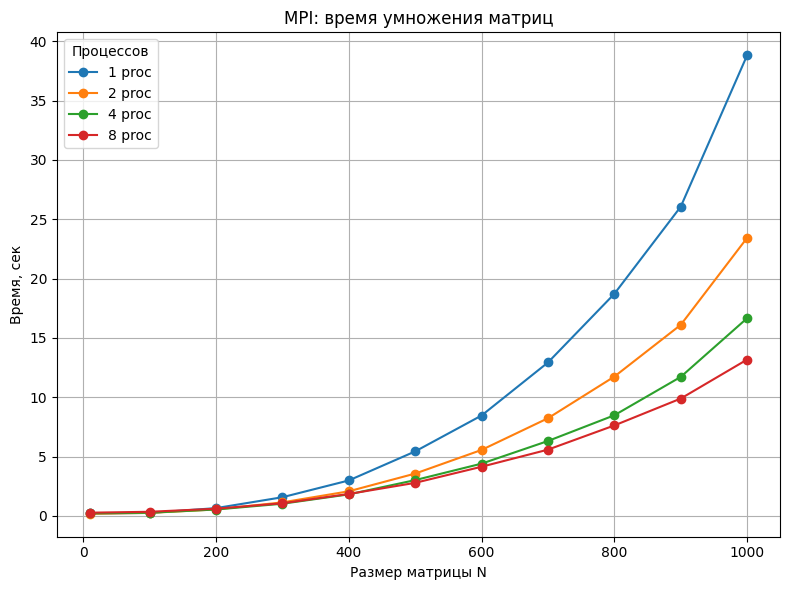

In [19]:
plot_results(results)


# Запуск на суперкомпьютере «Сергей Королёв»

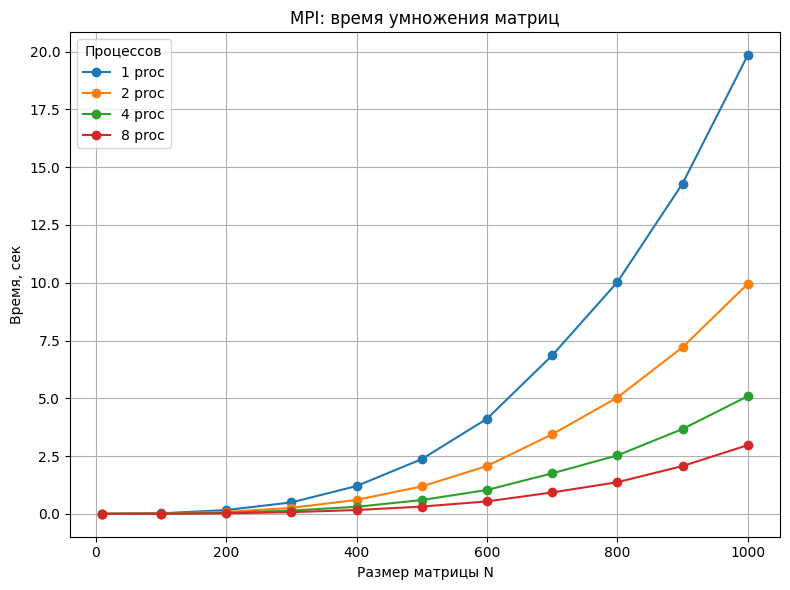

In [11]:
files = ['super_pc/1.txt', 'super_pc/2.txt', 'super_pc/4.txt', 'super_pc/8.txt']
procs_list = [1, 2, 4, 8]

results = {}

for file, procs in zip(files, procs_list):
    data = []
    with open(file, 'r') as f:
        for line in f:
            if line.strip():
                parts = line.strip().split()
                if len(parts) >= 2:
                    x_val, y_val = map(float, parts[:2])
                    data.append((x_val, y_val))
    results[procs] = data

plot_results(results)